## Análisis de datos - Clase 3
---

## Taller práctico parte 1 - análisis inicial de un dataset
---


Vamos a realizar una actividad con un dataset con datos del Servicio Meteorológico Nacional Argentino. El dataset contiene estadísticas climáticas normales (período 1991-2020).

Fuente: https://www.smn.gob.ar/descarga-de-datos

Consigna: identificar los valores faltantes y posibles causas.

Resumen de variables:
* estación, provincia, latitud, longitud, altitud, número y NroOACI (estos dos últimos identifican las estaciones)
* mes
* temperatura media, máxima y mínima
* humedad relativa
* velocidad del viento
* nubosidad total (en meteorología, la nubosidad se mide en octas (0, despejado - 8 completamente cubierto), que representan la fracción del cielo cubierta por nubes)
* precipitación
* frecuencia de días con precipitación superior a 0,1 mm.

In [9]:
import pandas as pd
import numpy as np
from datetime import timedelta
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
smn_historico = pd.read_csv('../datasets/smn/smn_historico.csv', na_values=['S/D'])

In [11]:
smn_historico.head()

,estacion,provincia,altura,numero,NroOACI,LAT_decimal,LON_decimal,mes_txt,prec_sup_1mm,humedad,nubosidad,prec_mm,temp,temp_max,temp_min,viento
0,AEROPARQUE AERO,CAPITAL FEDERAL,6.0,87582.0,SABE,-34.55,-58.416667,Ene,6.7,67.0,3.1,117.5,24.5,28.4,20.8,16.8
1,AEROPARQUE AERO,CAPITAL FEDERAL,6.0,87582.0,SABE,-34.55,-58.416667,Feb,6.0,69.8,3.2,112.3,23.7,27.3,20.2,15.8
2,AEROPARQUE AERO,CAPITAL FEDERAL,6.0,87582.0,SABE,-34.55,-58.416667,Mar,5.9,71.3,3.1,111.8,22.0,25.5,18.8,14.9
3,AEROPARQUE AERO,CAPITAL FEDERAL,6.0,87582.0,SABE,-34.55,-58.416667,Abr,6.6,73.6,3.5,108.3,18.5,22.0,15.3,13.9
4,AEROPARQUE AERO,CAPITAL FEDERAL,6.0,87582.0,SABE,-34.55,-58.416667,May,5.0,76.4,4.0,83.3,15.2,18.4,12.3,12.9


In [12]:
smn_historico.tail()

,estacion,provincia,altura,numero,NroOACI,LAT_decimal,LON_decimal,mes_txt,prec_sup_1mm,humedad,nubosidad,prec_mm,temp,temp_max,temp_min,viento
1171,VILLA REYNOLDS AERO,SAN LUIS,486.0,87448.0,SAOR,-33.716667,-65.366667,Ago,2.4,63.3,3.4,15.6,9.7,20.2,1.5,11.2
1172,VILLA REYNOLDS AERO,SAN LUIS,486.0,87448.0,SAOR,-33.716667,-65.366667,Sep,4.0,60.9,3.6,35.4,13.1,22.6,4.6,12.6
1173,VILLA REYNOLDS AERO,SAN LUIS,486.0,87448.0,SAOR,-33.716667,-65.366667,Oct,7.1,63.0,3.9,65.8,16.9,25.2,8.9,16.3
1174,VILLA REYNOLDS AERO,SAN LUIS,486.0,87448.0,SAOR,-33.716667,-65.366667,Nov,8.8,62.0,3.8,92.4,20.0,28.1,11.9,15.1
1175,VILLA REYNOLDS AERO,SAN LUIS,486.0,87448.0,SAOR,-33.716667,-65.366667,Dic,9.1,62.1,3.6,105.4,22.5,30.6,14.3,14.0


In [13]:
smn_historico.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1176 entries, 0 to 1175
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   estacion      1176 non-null   object 
 1   provincia     1152 non-null   object 
 2   altura        1152 non-null   float64
 3   numero        1152 non-null   float64
 4   NroOACI       1140 non-null   object 
 5   LAT_decimal   1152 non-null   float64
 6   LON_decimal   1152 non-null   float64
 7   mes_txt       1176 non-null   object 
 8   prec_sup_1mm  1061 non-null   float64
 9   humedad       1110 non-null   float64
 10  nubosidad     1166 non-null   float64
 11  prec_mm       1061 non-null   float64
 12  temp          1167 non-null   float64
 13  temp_max      1158 non-null   float64
 14  temp_min      1124 non-null   float64
 15  viento        708 non-null    float64
dtypes: float64(12), object(4)
memory usage: 147.1+ KB


In [14]:
smn_historico.isnull()

,estacion,provincia,altura,numero,NroOACI,LAT_decimal,LON_decimal,mes_txt,prec_sup_1mm,humedad,nubosidad,prec_mm,temp,temp_max,temp_min,viento
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1171,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1172,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1173,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1174,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [15]:
smn_historico.isna()

,estacion,provincia,altura,numero,NroOACI,LAT_decimal,LON_decimal,mes_txt,prec_sup_1mm,humedad,nubosidad,prec_mm,temp,temp_max,temp_min,viento
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1171,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1172,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1173,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1174,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [16]:
smn_historico.isna().sum()  

estacion          0
provincia        24
altura           24
numero           24
NroOACI          36
LAT_decimal      24
LON_decimal      24
mes_txt           0
prec_sup_1mm    115
humedad          66
nubosidad        10
prec_mm         115
temp              9
temp_max         18
temp_min         52
viento          468
dtype: int64

In [17]:
smn_historico.isna().mean().round(4)*100

estacion         0.00
provincia        2.04
altura           2.04
numero           2.04
NroOACI          3.06
LAT_decimal      2.04
LON_decimal      2.04
mes_txt          0.00
prec_sup_1mm     9.78
humedad          5.61
nubosidad        0.85
prec_mm          9.78
temp             0.77
temp_max         1.53
temp_min         4.42
viento          39.80
dtype: float64

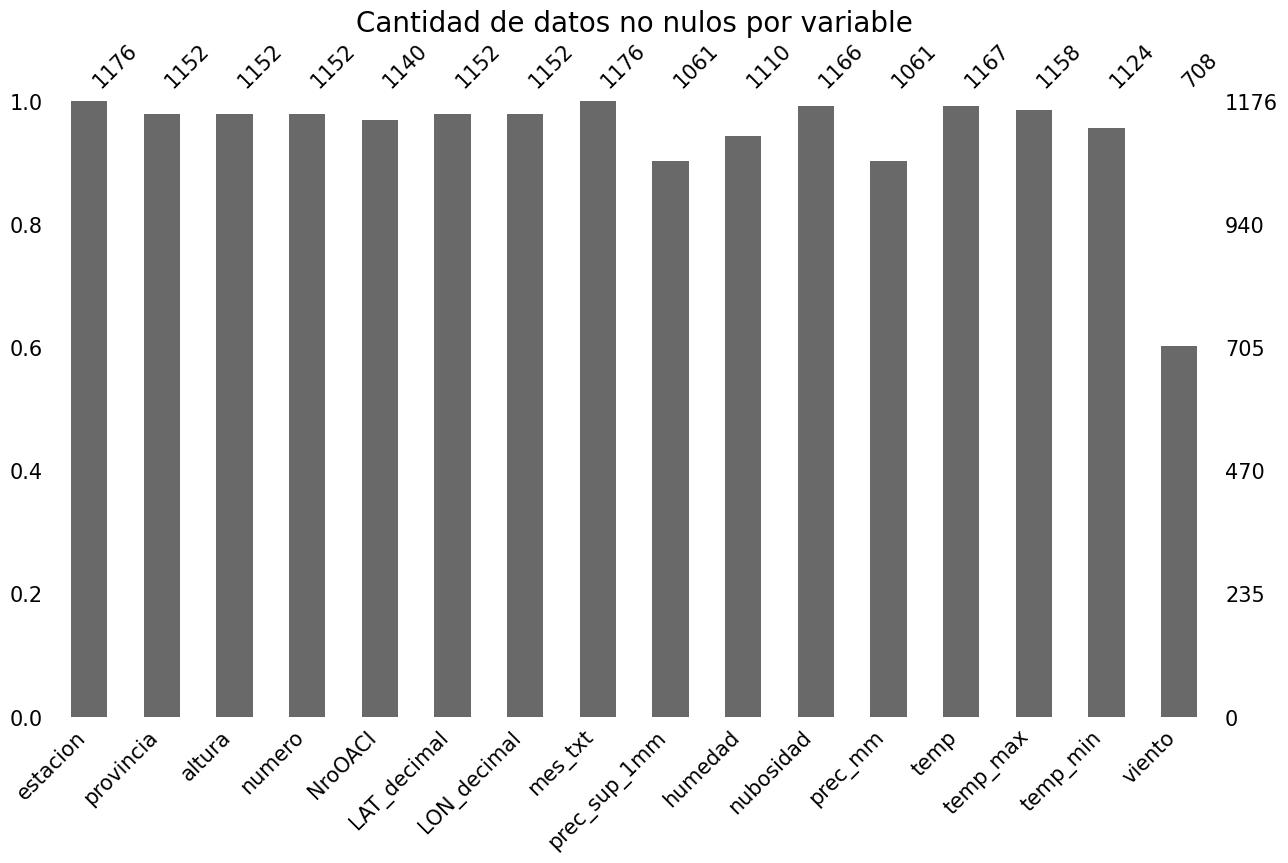

In [18]:
msno.bar(smn_historico, fontsize=15, figsize=(15,8))
plt.title("Cantidad de datos no nulos por variable", fontsize=20)
plt.show()

<Axes: >

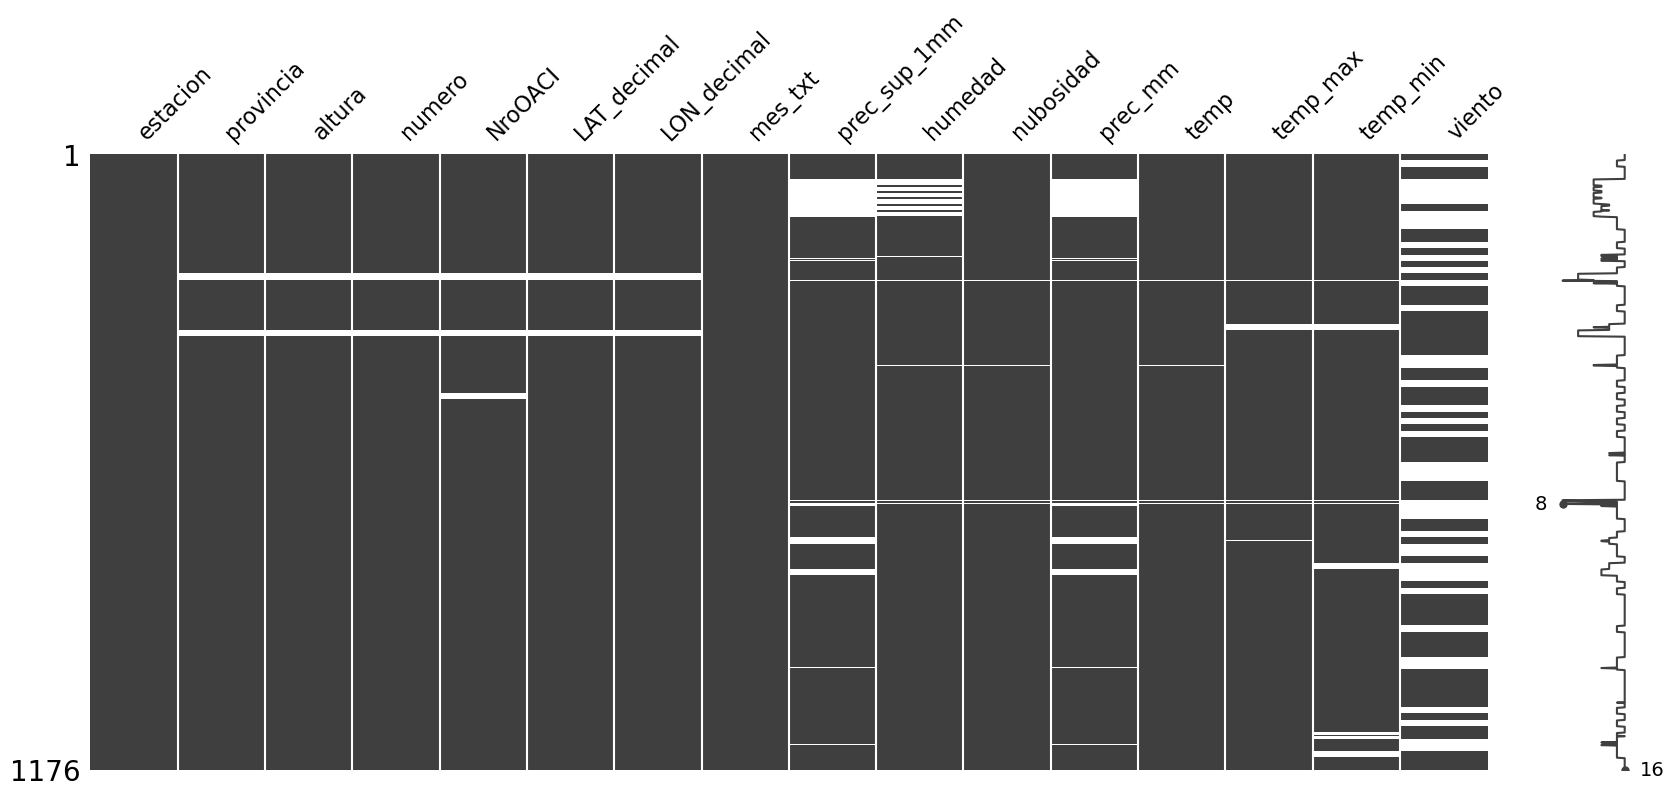

In [20]:
msno.matrix(smn_historico, figsize=(20,8))